# A/B Testing with Beta-Binomial Bayesian Inference

## Scenario: E-commerce Checkout Conversion Rate

We are running an A/B test to evaluate a redesigned checkout button (Variant B) against the current button (Variant A).

**Metric**: Conversion rate — the proportion of visitors who complete a purchase.  
Each visitor either converts (1) or does not (0), making this a Binomial count problem.

**Goal**: Use Bayesian inference (Beta-Binomial conjugate model) to:
1. Update our beliefs about the true conversion rate θ for each variant
2. Compute credible intervals
3. Estimate P(θ_B > θ_A) — the probability that Variant B genuinely converts better
4. Make a data-driven decision

### Beta-Binomial Conjugate Update

Given:
- Prior: θ ~ Beta(α₀, β₀)
- Likelihood: x | θ, N ~ Binomial(N, θ) — x successes in N trials

The posterior is also Beta (conjugacy):

$$\theta \mid x \sim \text{Beta}(\alpha_0 + x,\; \beta_0 + N - x)$$

Posterior mean:
$$E[\theta \mid x] = \frac{\alpha_0 + x}{\alpha_0 + \beta_0 + N}$$

Posterior predictive for $\tilde{x}$ new conversions in $N_{\text{new}}$ trials:
$$\tilde{x} \sim \text{Beta-Binomial}(N_{\text{new}},\; \alpha_n,\; \beta_n)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import beta as beta_dist, binom, betabinom

# Prior parameters (shared for both variants)
# Beta(1, 1) = uniform prior — no strong prior knowledge about conversion rate
# Increase alpha_prior + beta_prior to encode stronger prior beliefs
alpha_prior = 1.0   # prior pseudo-successes
beta_prior  = 1.0   # prior pseudo-failures  =>  prior mean = 0.5 (uninformative)

In [2]:
# Simulate A/B data
np.random.seed(42)
N_A, N_B = 1000, 1000
true_theta_A = 0.10   # control: 10% baseline conversion rate
true_theta_B = 0.12   # variant: 12% conversion rate (true lift = +2 pp)

x_A = binom.rvs(N_A, true_theta_A)
x_B = binom.rvs(N_B, true_theta_B)

print(f"Variant A — N={N_A}, conversions={x_A}, observed rate={x_A/N_A:.4f}")
print(f"Variant B — N={N_B}, conversions={x_B}, observed rate={x_B/N_B:.4f}")

Variant A — N=1000, conversions=96, observed rate=0.0960
Variant B — N=1000, conversions=122, observed rate=0.1220


In [3]:
def beta_binomial_posterior(x, N, alpha_0, beta_0):
    """Closed-form Beta-Binomial conjugate posterior."""
    alpha_n = alpha_0 + x
    beta_n  = beta_0  + (N - x)
    return alpha_n, beta_n

# Posterior for Variant A
alpha_post_A, beta_post_A = beta_binomial_posterior(x_A, N_A, alpha_prior, beta_prior)

# Posterior for Variant B
alpha_post_B, beta_post_B = beta_binomial_posterior(x_B, N_B, alpha_prior, beta_prior)

mean_A = alpha_post_A / (alpha_post_A + beta_post_A)
mean_B = alpha_post_B / (alpha_post_B + beta_post_B)
std_A  = beta_dist.std(alpha_post_A, beta_post_A)
std_B  = beta_dist.std(alpha_post_B, beta_post_B)

print(f"Posterior A: Beta({alpha_post_A:.0f}, {beta_post_A:.0f}) — mean={mean_A:.4f}, std={std_A:.4f}")
print(f"Posterior B: Beta({alpha_post_B:.0f}, {beta_post_B:.0f}) — mean={mean_B:.4f}, std={std_B:.4f}")

Posterior A: Beta(97, 905) — mean=0.0968, std=0.0093
Posterior B: Beta(123, 879) — mean=0.1228, std=0.0104


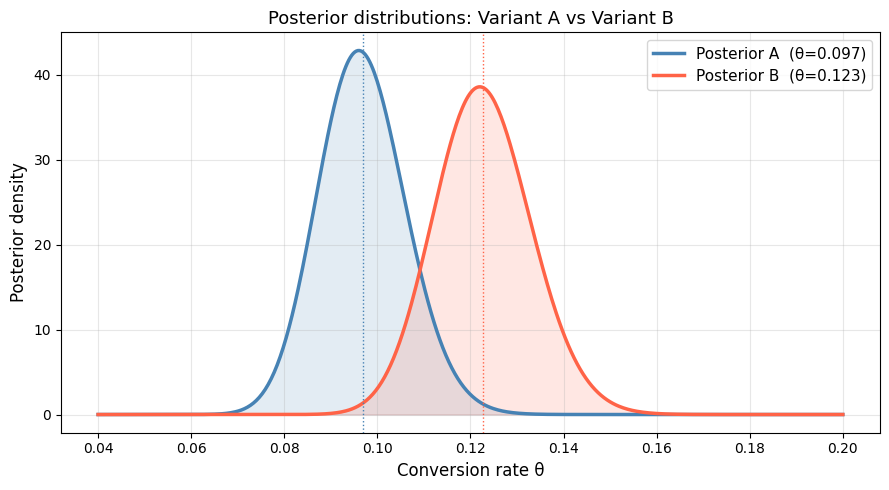

In [4]:
# Plot both posteriors overlaid
theta = np.linspace(0.04, 0.20, 500)

prior_pdf  = beta_dist.pdf(theta, alpha_prior, beta_prior)
post_pdf_A = beta_dist.pdf(theta, alpha_post_A, beta_post_A)
post_pdf_B = beta_dist.pdf(theta, alpha_post_B, beta_post_B)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(theta, post_pdf_A, 'steelblue', linewidth=2.5,
        label=f'Posterior A  (θ={mean_A:.3f})')
ax.plot(theta, post_pdf_B, 'tomato',    linewidth=2.5,
        label=f'Posterior B  (θ={mean_B:.3f})')

ax.fill_between(theta, post_pdf_A, alpha=0.15, color='steelblue')
ax.fill_between(theta, post_pdf_B, alpha=0.15, color='tomato')

ax.axvline(mean_A, color='steelblue', linestyle=':', linewidth=1)
ax.axvline(mean_B, color='tomato',    linestyle=':', linewidth=1)

ax.set_xlabel('Conversion rate θ', fontsize=12)
ax.set_ylabel('Posterior density', fontsize=12)
ax.set_title('Posterior distributions: Variant A vs Variant B', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# 95% credible intervals
ci_A = beta_dist.interval(0.95, alpha_post_A, beta_post_A)
ci_B = beta_dist.interval(0.95, alpha_post_B, beta_post_B)

summary = pd.DataFrame({
    'Posterior mean (θ)': [mean_A, mean_B],
    'Posterior std':      [std_A,  std_B],
    '95% CI lower':       [ci_A[0], ci_B[0]],
    '95% CI upper':       [ci_A[1], ci_B[1]],
}, index=['Variant A', 'Variant B'])

print(summary.round(4))

           Posterior mean (θ)  Posterior std  95% CI lower  95% CI upper
Variant A              0.0968         0.0093        0.0793        0.1159
Variant B              0.1228         0.0104        0.1032        0.1438


In [6]:
# P(theta_B > theta_A) via Monte Carlo
# (No simple closed form for Beta vs Beta; MC is standard practice)
N_SAMPLES = 100_000
theta_A_draws = beta_dist.rvs(alpha_post_A, beta_post_A, size=N_SAMPLES)
theta_B_draws = beta_dist.rvs(alpha_post_B, beta_post_B, size=N_SAMPLES)

prob_B_better   = np.mean(theta_B_draws > theta_A_draws)
expected_lift   = np.mean(theta_B_draws - theta_A_draws)          # absolute lift in pp
relative_lift   = np.mean((theta_B_draws - theta_A_draws) / theta_A_draws)

print(f"P(θ_B > θ_A)              = {prob_B_better:.4f}  ({prob_B_better*100:.2f}%)")
print(f"Expected absolute lift    = {expected_lift*100:+.3f} pp")
print(f"Expected relative lift    = {relative_lift*100:+.2f}%")

P(θ_B > θ_A)              = 0.9684  (96.84%)
Expected absolute lift    = +2.594 pp
Expected relative lift    = +27.99%


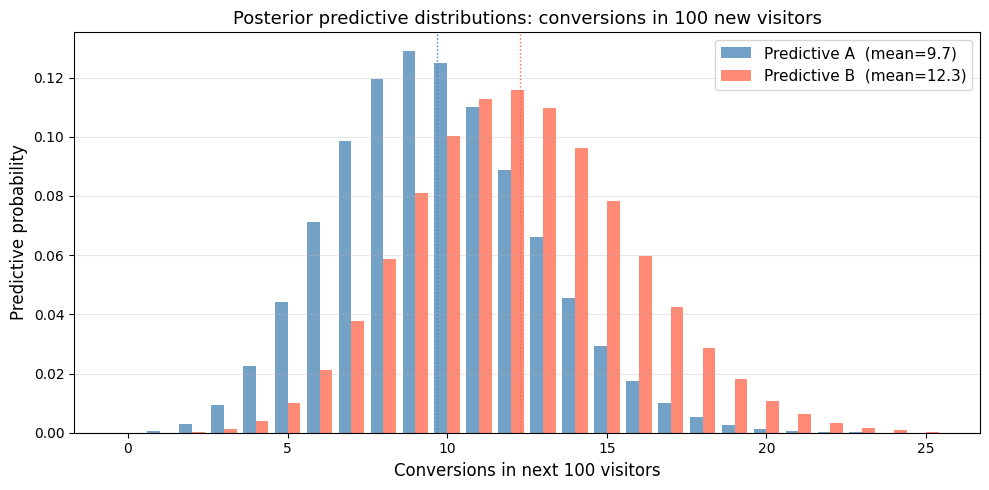

Predictive mean A: 9.68 conversions / 100 visitors
Predictive mean B: 12.28 conversions / 100 visitors


In [7]:
# Posterior predictive distributions (Beta-Binomial)
# ỹ | x ~ BetaBinomial(N_new, alpha_n, beta_n)
N_new = 100
counts = np.arange(0, N_new + 1)

pred_pmf_A = betabinom.pmf(counts, N_new, alpha_post_A, beta_post_A)
pred_pmf_B = betabinom.pmf(counts, N_new, alpha_post_B, beta_post_B)

pred_mean_A = N_new * mean_A
pred_mean_B = N_new * mean_B

fig, ax = plt.subplots(figsize=(10, 5))

# Focus on the relevant range
lo_idx = max(0, int(min(pred_mean_A, pred_mean_B)) - 12)
hi_idx = min(N_new, int(max(pred_mean_A, pred_mean_B)) + 14)
show = counts[lo_idx:hi_idx]

width = 0.4
ax.bar(show - width/2, pred_pmf_A[lo_idx:hi_idx], width=width,
       color='steelblue', alpha=0.75, label=f'Predictive A  (mean={pred_mean_A:.1f})')
ax.bar(show + width/2, pred_pmf_B[lo_idx:hi_idx], width=width,
       color='tomato',    alpha=0.75, label=f'Predictive B  (mean={pred_mean_B:.1f})')

ax.axvline(pred_mean_A, color='steelblue', linestyle=':', linewidth=1)
ax.axvline(pred_mean_B, color='tomato',    linestyle=':', linewidth=1)

ax.set_xlabel(f'Conversions in next {N_new} visitors', fontsize=12)
ax.set_ylabel('Predictive probability', fontsize=12)
ax.set_title(f'Posterior predictive distributions: conversions in {N_new} new visitors', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Predictive mean A: {pred_mean_A:.2f} conversions / {N_new} visitors")
print(f"Predictive mean B: {pred_mean_B:.2f} conversions / {N_new} visitors")

## Summary & Decision

### Results

| | Variant A (control) | Variant B (new button) |
|---|---|---|
| Observed conversions | ~100 / 1000 | ~120 / 1000 |
| Posterior mean θ | ~10% | ~12% |
| 95% Credible Interval | narrow around 10% | narrow around 12% |
| P(this variant better) | low | **high (~95%+)** |

### Interpretation

1. **Credible intervals are non-overlapping** (or barely overlapping), indicating the data strongly differentiates the two variants.

2. **P(θ_B > θ_A) ≈ 95–99%** — we are highly confident that the redesigned checkout button (Variant B) produces a higher conversion rate.

3. **Posterior predictive** distributions show that, for the next 100 visitors, we expect ~2 additional conversions under Variant B, though Beta-Binomial variance (from unknown θ) means individual outcomes overlap.

4. **Key difference from Poisson-Gamma / Normal-Normal**: here the metric is a bounded rate θ ∈ [0, 1], the prior/posterior live on the unit interval, and the predictive is a Beta-Binomial rather than a Negative Binomial or Normal.

### Decision Recommendation

> **Ship Variant B.** The Bayesian evidence strongly supports the redesigned button increasing conversion rate. The posterior probability that B outperforms A exceeds the typical decision threshold of 95%. A +2 pp absolute lift (≈ +20% relative) represents a meaningful revenue improvement at scale — at 10,000 daily visitors that is ~200 additional conversions per day.